# COVID-19 Country-wise Data Analysis
## Introduction
In this project, I have analyzed
COVID-19 data from India.
I used Python,Pandas,Numpy and Matplotlibto understand confirmed cases
recoveries,deaths and active cases.


## 1. Setup and Data Loading

In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\admin\\Downloads\\country_wise_latest (3).csv')
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


## 2. Dataset Overview

In [10]:
print(f"Shape: {df.shape[0]} countries, {df.shape[1]} columns")
print("\nColumns:", list(df.columns))


Shape: 187 countries, 15 columns

Columns: ['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases', 'Recovered / 100 Cases', 'Deaths / 100 Recovered', 'Confirmed last week', '1 week change', '1 week % increase', 'WHO Region']


In [11]:
df.dtypes

Country/Region                str
Confirmed                   int64
Deaths                      int64
Recovered                   int64
Active                      int64
New cases                   int64
New deaths                  int64
New recovered               int64
Deaths / 100 Cases        float64
Recovered / 100 Cases     float64
Deaths / 100 Recovered    float64
Confirmed last week         int64
1 week change               int64
1 week % increase         float64
WHO Region                    str
dtype: object

In [12]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing cells:", df.isnull().sum().sum())

Missing values per column:
Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

Total missing cells: 0


No missing values were found across any of the 187 rows, so no imputation or cleaning was required.

## 3. Descriptive Statistics

In [13]:
numeric_cols = ['Confirmed','Deaths','Recovered','Active','New cases',
                 'New deaths','New recovered']
desc = df[numeric_cols].describe().T
desc['sum'] = df[numeric_cols].sum()
desc['skew'] = df[numeric_cols].skew()
desc

,count,mean,std,min,25%,50%,75%,max,sum,skew
Confirmed,187.0,88130.935829,383318.663831,10.0,1114.0,5059.0,40460.5,4290259.0,16480485,8.725676
Deaths,187.0,3497.518717,14100.002482,0.0,18.5,108.0,734.0,148011.0,654036,7.464481
Recovered,187.0,50631.481283,190188.189643,0.0,626.5,2815.0,22606.0,1846641.0,9468087,6.983644
Active,187.0,34001.935829,213326.173371,0.0,141.5,1600.0,9149.0,2816444.0,6358362,12.182067
New cases,187.0,1222.957219,5710.374790,0.0,4.0,49.0,419.5,56336.0,228693,7.720320
New deaths,187.0,28.957219,120.037173,0.0,0.0,1.0,6.0,1076.0,5415,5.970033
New recovered,187.0,933.812834,4197.719635,0.0,0.0,22.0,221.0,33728.0,174623,6.769567


### Global Totals

In [14]:
total_confirmed = np.sum(df['Confirmed'].values)
total_deaths    = np.sum(df['Deaths'].values)
total_recovered = np.sum(df['Recovered'].values)
total_active    = np.sum(df['Active'].values)
global_cfr      = np.round(total_deaths/total_confirmed*100, 2)
global_recovery = np.round(total_recovered/total_confirmed*100, 2)

print(f"Total Confirmed : {total_confirmed:,}")
print(f"Total Deaths    : {total_deaths:,}")
print(f"Total Recovered : {total_recovered:,}")
print(f"Total Active    : {total_active:,}")
print(f"Global Case Fatality Rate : {global_cfr}%")
print(f"Global Recovery Rate      : {global_recovery}%")

Total Confirmed : 16,480,485
Total Deaths    : 654,036
Total Recovered : 9,468,087
Total Active    : 6,358,362
Global Case Fatality Rate : 3.97%
Global Recovery Rate      : 57.45%


Roughly 57% of confirmed cases had recovered at the time of reporting, while the global case fatality rate stood at approximately 4%.

## 4. Top / Bottom Countries

### 4.1 Top 10 Countries by Confirmed Cases

In [15]:
top10_confirmed = df.nlargest(10, 'Confirmed')[['Country/Region','Confirmed','Deaths','Recovered']]
top10_confirmed

,Country/Region,Confirmed,Deaths,Recovered
173,US,4290259,148011,1325804
23,Brazil,2442375,87618,1846641
79,India,1480073,33408,951166
138,Russia,816680,13334,602249
154,South Africa,452529,7067,274925
111,Mexico,395489,44022,303810
132,Peru,389717,18418,272547
35,Chile,347923,9187,319954
177,United Kingdom,301708,45844,1437
81,Iran,293606,15912,255144


### 4.2 Top 10 Countries by Deaths

In [16]:
top10_deaths = df.nlargest(10, 'Deaths')[['Country/Region','Deaths','Deaths / 100 Cases']]
top10_deaths

,Country/Region,Deaths,Deaths / 100 Cases
173,US,148011,3.45
23,Brazil,87618,3.59
177,United Kingdom,45844,15.19
111,Mexico,44022,11.13
85,Italy,35112,14.26
79,India,33408,2.26
61,France,30212,13.71
157,Spain,28432,10.44
132,Peru,18418,4.73
81,Iran,15912,5.42


### 4.3 Top 10 Countries by Case Fatality Rate (min. 1000 confirmed cases)

In [17]:
subset = df[df['Confirmed'] > 1000]
top10_cfr = subset.nlargest(10, 'Deaths / 100 Cases')[['Country/Region','Deaths / 100 Cases','Confirmed']]
top10_cfr

,Country/Region,Deaths / 100 Cases,Confirmed
184,Yemen,28.56,1691
177,United Kingdom,15.19,301708
16,Belgium,14.79,66428
85,Italy,14.26,246286
61,France,13.71,220352
77,Hungary,13.40,4448
120,Netherlands,11.53,53413
111,Mexico,11.13,395489
157,Spain,10.44,272421
32,Canada,7.68,116458


Yemen shows an exceptionally high fatality rate (28.56%), which — given its comparatively low case count — likely reflects limited testing capacity rather than true disease severity.

## 5. WHO Region-wise Analysis

In [18]:
region_summary = df.groupby('WHO Region')[numeric_cols].sum()
region_summary['Case Fatality Rate (%)'] = np.round(
    region_summary['Deaths']/region_summary['Confirmed']*100, 2)
region_summary['Recovery Rate (%)'] = np.round(
    region_summary['Recovered']/region_summary['Confirmed']*100, 2)
region_summary = region_summary.sort_values('Confirmed', ascending=False)
region_summary

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Case Fatality Rate (%),Recovery Rate (%)
WHO Region,,,,,,,,,
Americas,8839286,342732,4468616,4027938,129531,3555,94776,3.88,50.55
Europe,3299523,211144,1993723,1094656,22294,304,11732,6.40,60.42
South-East Asia,1835297,41349,1156933,637015,48993,734,37582,2.25,63.04
Eastern Mediterranean,1490744,38339,1201400,251005,12410,445,14843,2.57,80.59
Africa,723207,12223,440645,270339,12176,353,14563,1.69,60.93
Western Pacific,292428,8249,206770,77409,3289,24,1127,2.82,70.71


The Americas region dominates global case counts (~53% of the world total) but has the lowest recovery rate (50.6%), while the Eastern Mediterranean region shows the best recovery outcomes (80.6%).

## 6. Correlation Analysis

In [19]:
corr = df[numeric_cols + ['Deaths / 100 Cases','Recovered / 100 Cases']].corr()
np.round(corr, 2)

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases
Confirmed,1.00,0.93,0.91,0.93,0.91,0.87,0.86,0.06,-0.06
Deaths,0.93,1.00,0.83,0.87,0.81,0.81,0.77,0.25,-0.11
Recovered,0.91,0.83,1.00,0.68,0.82,0.82,0.92,0.05,0.03
Active,0.93,0.87,0.68,1.00,0.85,0.78,0.67,0.05,-0.13
New cases,0.91,0.81,0.82,0.85,1.00,0.94,0.91,0.02,-0.08
New deaths,0.87,0.81,0.82,0.78,0.94,1.00,0.89,0.06,-0.06
New recovered,0.86,0.77,0.92,0.67,0.91,0.89,1.00,0.02,-0.02
Deaths / 100 Cases,0.06,0.25,0.05,0.05,0.02,0.06,0.02,1.00,-0.17
Recovered / 100 Cases,-0.06,-0.11,0.03,-0.13,-0.08,-0.06,-0.02,-0.17,1.00


## 7. Visualizations

### 7.1 Top 10 Countries by Confirmed Cases

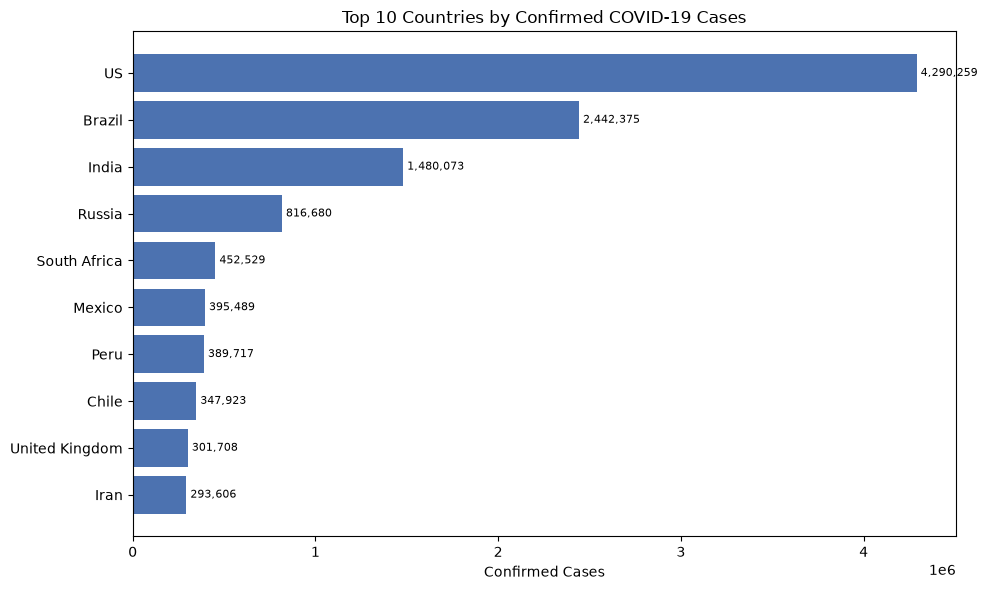

In [20]:
fig, ax = plt.subplots(figsize=(10,6))
data = top10_confirmed.sort_values('Confirmed')
ax.barh(data['Country/Region'], data['Confirmed'], color='#4C72B0')
ax.set_xlabel('Confirmed Cases')
ax.set_title('Top 10 Countries by Confirmed COVID-19 Cases')
for i,v in enumerate(data['Confirmed']):
    ax.text(v, i, f' {v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 7.2 Top 10 Countries by Deaths

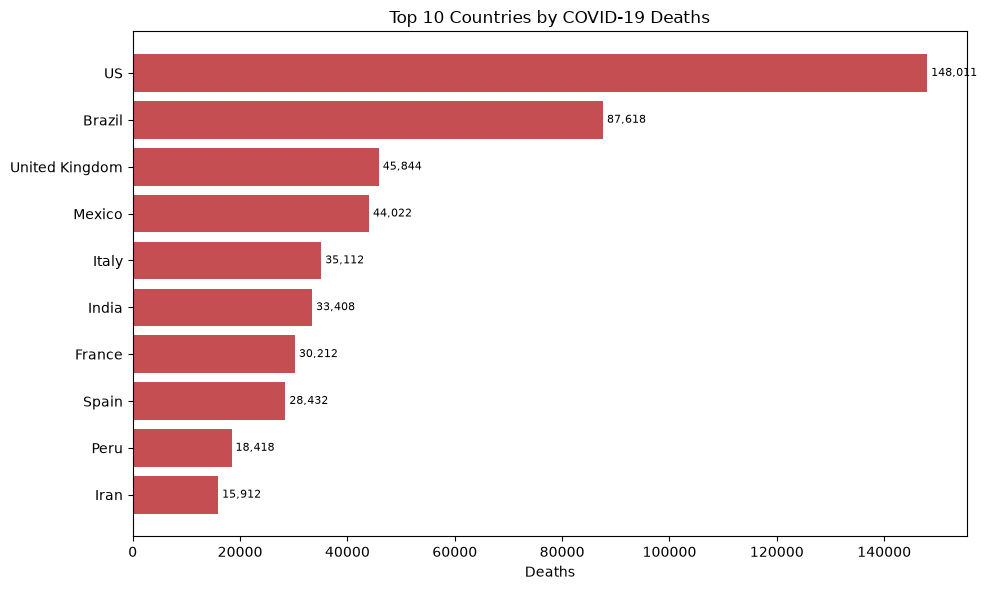

In [21]:
fig, ax = plt.subplots(figsize=(10,6))
data = top10_deaths.sort_values('Deaths')
ax.barh(data['Country/Region'], data['Deaths'], color='#C44E52')
ax.set_xlabel('Deaths')
ax.set_title('Top 10 Countries by COVID-19 Deaths')
for i,v in enumerate(data['Deaths']):
    ax.text(v, i, f' {v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

### 7.3 Share of Global Confirmed Cases by WHO Region

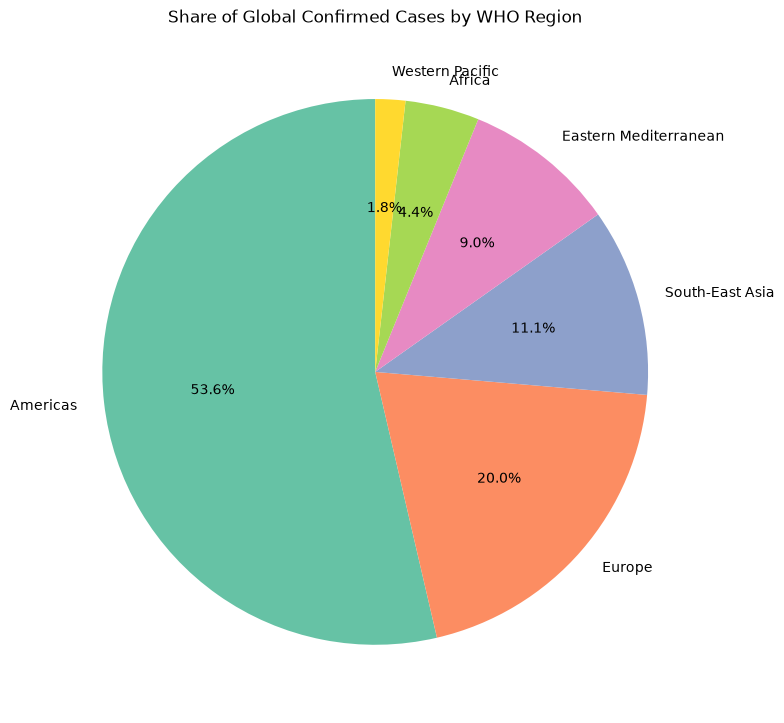

In [22]:
fig, ax = plt.subplots(figsize=(8,8))
ax.pie(region_summary['Confirmed'], labels=region_summary.index, autopct='%1.1f%%',
       startangle=90, colors=plt.cm.Set2.colors)
ax.set_title('Share of Global Confirmed Cases by WHO Region')
plt.tight_layout()
plt.show()

### 7.4 WHO Region-wise Statistics (Grouped Bar Chart)

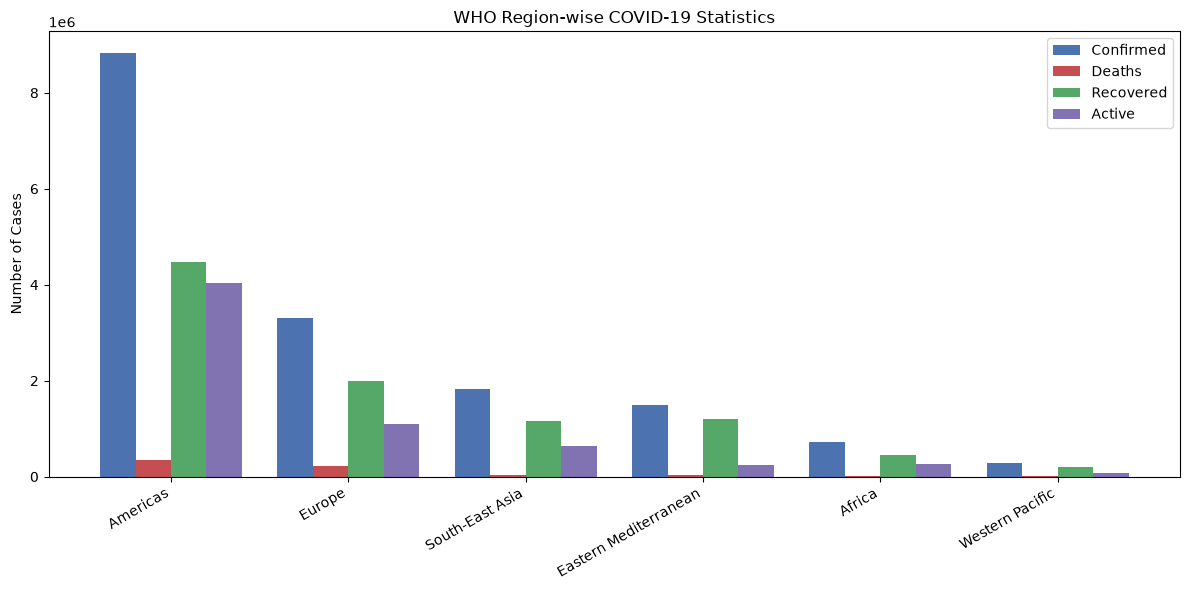

In [23]:
fig, ax = plt.subplots(figsize=(12,6))
x = np.arange(len(region_summary))
width = 0.2
cols_to_plot = ['Confirmed','Deaths','Recovered','Active']
colors = ['#4C72B0','#C44E52','#55A868','#8172B2']
for i,(col,c) in enumerate(zip(cols_to_plot,colors)):
    ax.bar(x + i*width, region_summary[col], width, label=col, color=c)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(region_summary.index, rotation=30, ha='right')
ax.set_ylabel('Number of Cases')
ax.set_title('WHO Region-wise COVID-19 Statistics')
ax.legend()
plt.tight_layout()
plt.show()

### 7.5 Death Rate vs Recovery Rate by Country

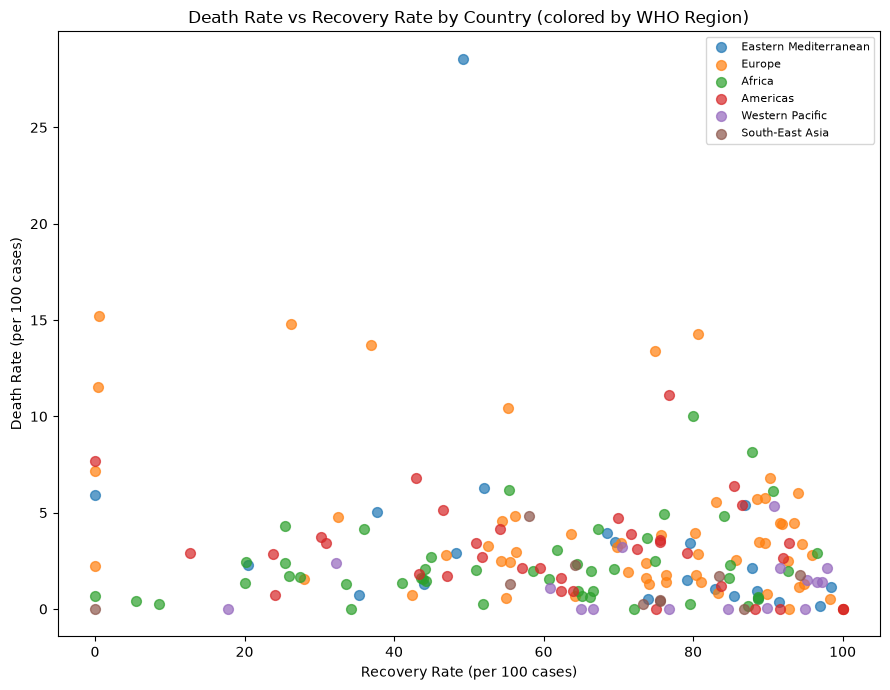

In [24]:
fig, ax = plt.subplots(figsize=(9,7))
regions = df['WHO Region'].unique()
cmap = plt.cm.tab10
for i, region in enumerate(regions):
    sub = df[df['WHO Region']==region]
    ax.scatter(sub['Recovered / 100 Cases'], sub['Deaths / 100 Cases'],
               label=region, alpha=0.7, s=50, color=cmap(i))
ax.set_xlabel('Recovery Rate (per 100 cases)')
ax.set_ylabel('Death Rate (per 100 cases)')
ax.set_title('Death Rate vs Recovery Rate by Country (colored by WHO Region)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 7.6 Distribution of Confirmed Cases (log scale)

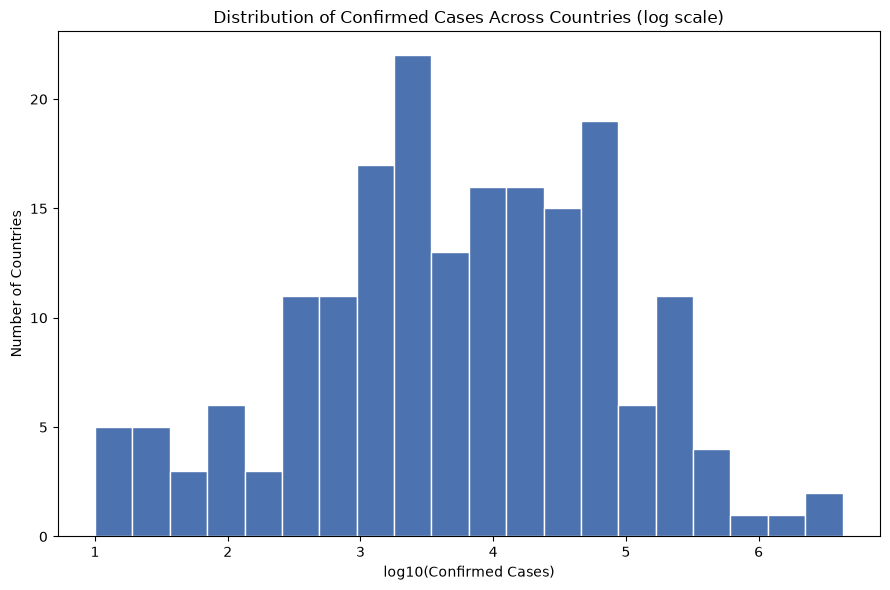

In [25]:
fig, ax = plt.subplots(figsize=(9,6))
ax.hist(np.log10(df['Confirmed'].replace(0,1)), bins=20, color='#4C72B0', edgecolor='white')
ax.set_xlabel('log10(Confirmed Cases)')
ax.set_ylabel('Number of Countries')
ax.set_title('Distribution of Confirmed Cases Across Countries (log scale)')
plt.tight_layout()
plt.show()

### 7.7 Correlation Heatmap

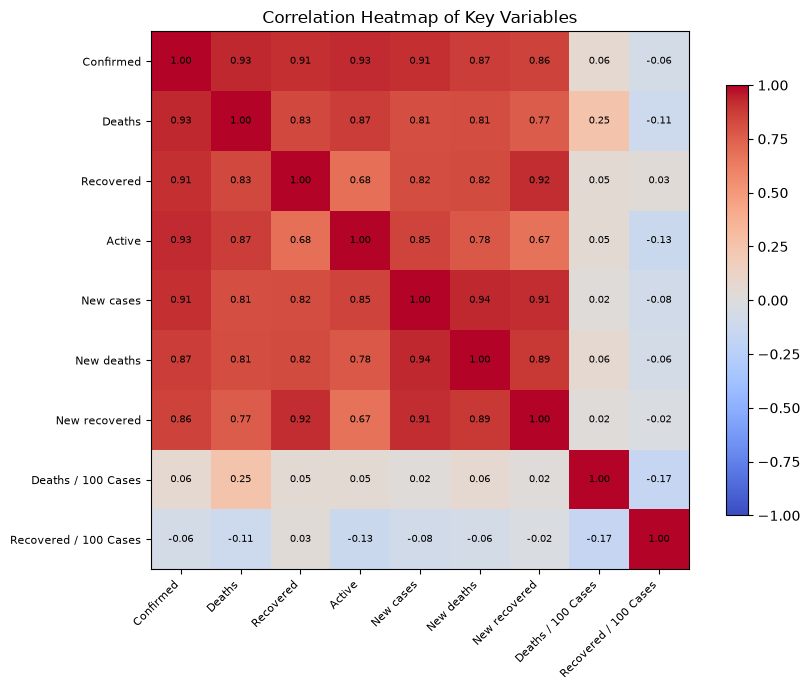

In [26]:
fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                 color='black', fontsize=7)
ax.set_title('Correlation Heatmap of Key Variables')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### 7.8 Fastest Growing Countries (1-week % increase)

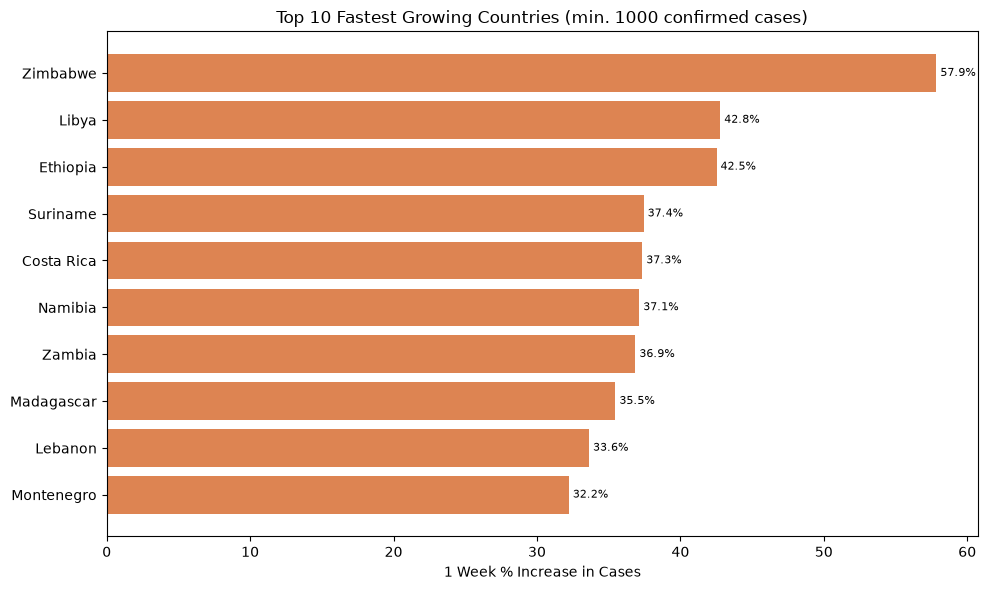

In [27]:
fig, ax = plt.subplots(figsize=(10,6))
fastest = df[df['Confirmed']>1000].nlargest(10, '1 week % increase')[['Country/Region','1 week % increase']].sort_values('1 week % increase')
ax.barh(fastest['Country/Region'], fastest['1 week % increase'], color='#DD8452')
ax.set_xlabel('1 Week % Increase in Cases')
ax.set_title('Top 10 Fastest Growing Countries (min. 1000 confirmed cases)')
for i,v in enumerate(fastest['1 week % increase']):
    ax.text(v, i, f' {v:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Conclusion


- The global case fatality rate (~4%) masks wide variation — several developed European nations show fatality rates 3–4x the global average.
- The Americas region carries the largest case burden and lowest recovery rate among WHO regions, while the Eastern Mediterranean region shows the best recovery outcomes.
- Case counts, deaths, recoveries and active cases are strongly inter-correlated (driven by outbreak scale), whereas rate-based metrics (CFR, recovery rate) behave independently.
- Growth-rate analysis shows the pandemic was still expanding rapidly in several smaller-outbreak countries at the time of reporting.

